# 1. Read in the store_income_data_task.csv file

In [2]:
import pandas as pd
import numpy as np

# Scaling modules
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Plotting modules
import seaborn as sns
import matplotlib.pyplot as plt

# Ensures the same random data is used each time you execute the code
np.random.seed(0)

# 2. Display the first observations.

In [ ]:
# Read data
data = pd.read_csv('store_income_data_.csv')

# Display first five observations
data.head()


,id,store_name,store_email,department,income,date_measured,country
0,1,"Cullen/Frost Bankers, Inc.",NaN,Clothing,$54438554.24,14 July 2006,UK
1,2,Nordson Corporation,NaN,Tools,$41744177.01,3 December 2006,united states of america
2,3,"Stag Industrial, Inc.",NaN,Beauty,$36152340.34,12 August 2003,UNITED STATES
3,4,FIRST REPUBLIC BANK,ecanadine3@fc2.com,Automotive,$8928350.04,26 October 2006,UK
4,5,Mercantile Bank Corporation,NaN,Baby,$33552742.32,24 December 1973,UK


# 3. Get the NO. of missing values per column and print the results

In [11]:
# Get the number of missing values per column
missing_values_per_column = data.isnull().sum()

missing_values_per_column[0:8]

id                 0
store_name         0
store_email      587
department        27
income             0
date_measured      0
country            0
dtype: int64

## Visualise the "EG.ELC.ACCS.ZS" column from the countries dataset using a histogram. Then, scale the column using the appropriate scaling method (normalisation or standardisation). Finally, visualise the original and scaled data alongside each other. Note EG.ELC.ACCS.ZS is the percentage of the population with access to electricity.

# ANSWER:

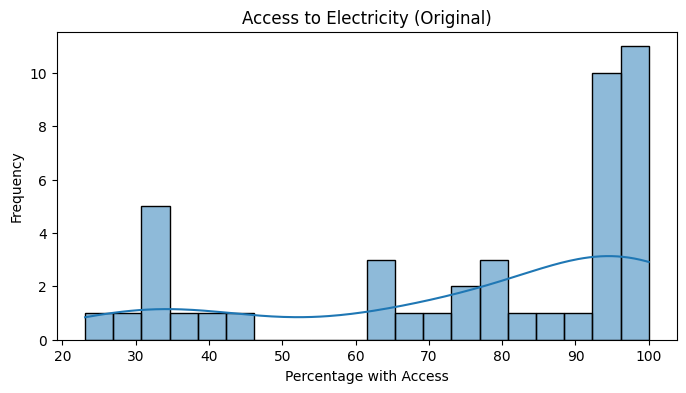

In [12]:
# Load and visualise the original data

# Load your dataset
data = pd.read_csv('countries.csv')

# Plot histogram of the original column
plt.figure(figsize=(8, 4))
sns.histplot(data['EG.ELC.ACCS.ZS'].dropna(), kde=True, bins=20)
plt.title('Access to Electricity (Original)')
plt.xlabel('Percentage with Access')
plt.ylabel('Frequency')
plt.show()

In [13]:
# I chose Normalisation.

# Scale the column:
scaler = MinMaxScaler()

# Reshape required because sklearn expects 2D input
scaled_values = scaler.fit_transform(data[['EG.ELC.ACCS.ZS']])

# Add scaled column to DataFrame
data['electricity_normalized'] = scaled_values

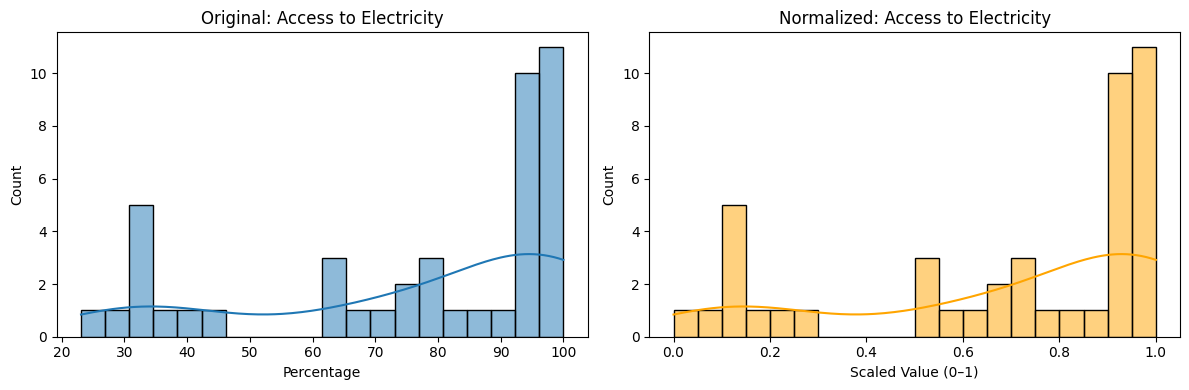

In [14]:
# Visualising the Original and Scaled data.

plt.figure(figsize=(12, 4))

# Original
plt.subplot(1, 2, 1)
sns.histplot(data['EG.ELC.ACCS.ZS'].dropna(), kde=True, bins=20)
plt.title('Original: Access to Electricity')
plt.xlabel('Percentage')

# Scaled
plt.subplot(1, 2, 2)
sns.histplot(data['electricity_normalized'].dropna(), kde=True, bins=20, color='orange')
plt.title('Normalized: Access to Electricity')
plt.xlabel('Scaled Value (0–1)')

plt.tight_layout()
plt.show()
